In [115]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier

In [117]:
df = pd.read_csv('CT_PET1_AfterComet.csv')
print(f"Dataset successfully loaded. Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")

Dataset successfully loaded. Shape: 734 rows, 294 columns.



In [118]:
clean_feature_names = [f.replace('[', '_').replace(']', '_').replace('<', '_').replace('>', '_').replace('-', '_').replace(':', '_')
                     for f in df.columns]
df.columns = clean_feature_names

print("Feature names sanitized! (Forbidden characters [ ] < : removed)")

Feature names sanitized! (Forbidden characters [ ] < : removed)


In [119]:
print("--- Dataset Info ---")
print(df.info())
print("\n--- First 3 Rows ---")
print(df.head(3))

metadata_cols = ['INFO_PatientName', 'INFO_NameOfRoi', 'Batch', 'label']
feature_cols = [col for col in df.columns if col not in metadata_cols]

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Columns: 294 entries, INFO_PatientName to PET1_GLSZM_ZoneSizeEntropy(IBSI_GU8N)
dtypes: float64(290), int64(2), object(2)
memory usage: 1.6+ MB
None

--- First 3 Rows ---
  INFO_PatientName INFO_NameOfRoi  label  Batch  \
0              CT1       Seg1_#11      0      1   
1              CT1       Seg1_#10      0      1   
2              CT1       Seg1_#33      1      1   

   CT_MORPHOLOGICAL_Volume(IBSI_RNU0)_cm3_  \
0                              -130.879031   
1                               -44.598042   
2                                14.415017   

   CT_MORPHOLOGICAL_ApproximateVolume(IBSI_YEKZ)_cm3_  \
0                                        -130.850454    
1                                         -44.531759    
2                                          14.463025    

   CT_MORPHOLOGICAL_voxelsCounting(IBSI_No)_#vx_  \
0                                 -130850.452882   
1            

In [120]:
print("\n--- Patient and Batch Unique Counts ---")
print(f"Unique Patients: {df['INFO_PatientName'].nunique()}")
print(f"Unique Regions of Interest (ROIs): {df['INFO_NameOfRoi'].nunique()}")
print(f"Unique Batches: {df['Batch'].nunique()}")

# repeated patients
patient_counts = df['INFO_PatientName'].value_counts()
print(f"Max samples for a single patient: {patient_counts.max()}")
print(f"Min samples for a single patient: {patient_counts.min()}")


--- Patient and Batch Unique Counts ---
Unique Patients: 24
Unique Regions of Interest (ROIs): 734
Unique Batches: 2
Max samples for a single patient: 108
Min samples for a single patient: 10


In [ ]:
print("\n--- Summary Statistics for Key Morphological Features ---")
print(df[feature_cols[:5]].describe().T)


--- Summary Statistics for Key Morphological Features ---
                                                    count           mean  \
CT_MORPHOLOGICAL_Volume(IBSI_RNU0)_cm3_             734.0     211.550192   
CT_MORPHOLOGICAL_ApproximateVolume(IBSI_YEKZ)_cm3_  734.0     211.662614   
CT_MORPHOLOGICAL_voxelsCounting(IBSI_No)_#vx_       734.0  211662.613547   
CT_MORPHOLOGICAL_SurfaceArea(IBSI_C0JK)_cm2_        734.0     267.130794   
CT_MORPHOLOGICAL_SurfaceToVolumeRatio(IBSI_2PR5...  734.0       3.783901   

                                                              std  \
CT_MORPHOLOGICAL_Volume(IBSI_RNU0)_cm3_                452.616487   
CT_MORPHOLOGICAL_ApproximateVolume(IBSI_YEKZ)_cm3_     452.712597   
CT_MORPHOLOGICAL_voxelsCounting(IBSI_No)_#vx_       452712.595091   
CT_MORPHOLOGICAL_SurfaceArea(IBSI_C0JK)_cm2_           477.117222   
CT_MORPHOLOGICAL_SurfaceToVolumeRatio(IBSI_2PR5...       2.179618   

                                                              min  \


In [122]:
print("\n--- Missing and Infinite Values Check ---")
null_counts = df[feature_cols].isnull().sum()
inf_counts = df[feature_cols].apply(lambda x: np.isinf(x).sum())

missing_summary = pd.DataFrame({'Missing (NaN)': null_counts, 'Infinite (Inf)': inf_counts})
problematic_cols = missing_summary[(missing_summary['Missing (NaN)'] > 0) | (missing_summary['Infinite (Inf)'] > 0)]

if not problematic_cols.empty:
    print("Features containing NaN or Inf values:")
    print(problematic_cols)
else:
    print("Clean! No missing (NaN) or infinite (Inf) values found in the feature columns.")


--- Missing and Infinite Values Check ---
Clean! No missing (NaN) or infinite (Inf) values found in the feature columns.


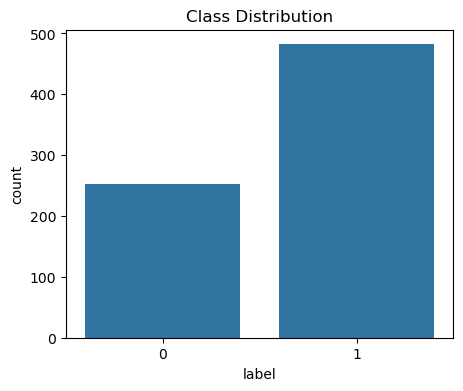

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.show()

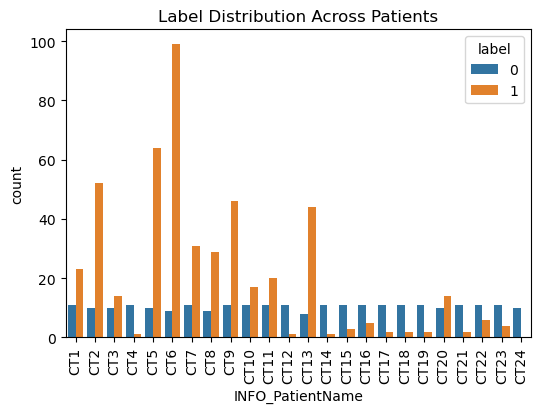

In [124]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="INFO_PatientName", hue="label")
plt.xticks(rotation=90)
plt.title("Label Distribution Across Patients")
plt.show()

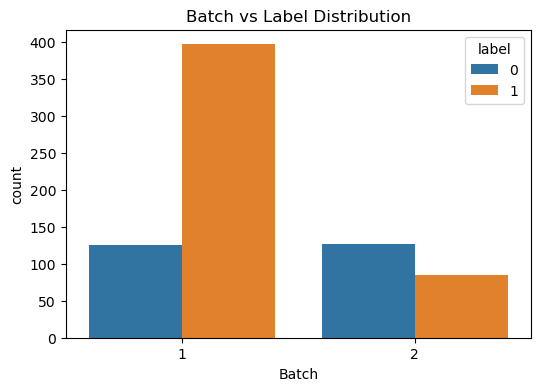

In [125]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Batch", hue="label")
plt.title("Batch vs Label Distribution")
plt.show()

In [ ]:
metadata_cols = ['INFO_PatientName', 'INFO_NameOfRoi', 'Batch', 'label']
feature_cols = [col for col in df.columns if col not in metadata_cols]

y = df["label"].values
groups = df["INFO_PatientName"].values


X = df.drop(columns=["label", "INFO_PatientName"])

X = X.drop(columns=["Batch", "INFO_NameOfRoi"], errors="ignore")

X = X.select_dtypes(include=[np.number])

X = X.replace([np.inf, -np.inf], np.nan)


In [127]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np

class CorrelationFilter(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def fit(self, X, y=None):

        X_df = pd.DataFrame(X)

        corr = X_df.corr().abs()

        upper = corr.where(
            np.triu(np.ones(corr.shape), k=1).astype(bool)
        )

        self.keep_columns_ = [
            col for col in upper.columns
            if not any(upper[col] > self.threshold)
        ]

        return self

    def transform(self, X):

        X_df = pd.DataFrame(X)

        return X_df.iloc[:, self.keep_columns_]

In [128]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

feature_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=300, random_state=42),
    max_features=10
)

In [129]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def build_pipeline(model):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("corr_filter", CorrelationFilter(threshold=0.95)),
        ("feature_select", feature_selector),
        ("classifier", model)
    ])

In [130]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier


models = {
    "LogReg": LogisticRegression(max_iter=2000),
    "LinearSVM": SVC(kernel="linear", probability=True),
    "RBF_SVM": SVC(kernel="rbf", probability=True),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
    "NaiveBayes": GaussianNB()
}

param_grids = {
    "LogReg": {
        "classifier__C": [0.01, 0.1, 1, 10]
    },

    "LinearSVM": {
        "classifier__C": [0.01, 0.1, 1, 10]
    },

    "RBF_SVM": {
        "classifier__C": [0.1, 1, 10],
        "classifier__gamma": ["scale", 0.01, 0.1]
    },

    "RandomForest": {
        "classifier__n_estimators": [100, 300],
        "classifier__max_depth": [3, 5, None]
    },

    "XGBoost": {
        "classifier__max_depth": [2, 3, 4],
        "classifier__learning_rate": [0.01, 0.1]
    },

    "NaiveBayes": {}
}

In [131]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate


outer_cv = GroupKFold(n_splits=5)
inner_cv = GroupKFold(n_splits=3)

results = []

for model_name, model in models.items():

    print(f"\nRunning model: {model_name}")

    outer_scores = []

    for train_idx, test_idx in outer_cv.split(X, y, groups):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        groups_train = groups[train_idx]

        pipeline = build_pipeline(model)

        search = GridSearchCV(
            pipeline,
            param_grids[model_name],
            cv=inner_cv,
            scoring="roc_auc",
            n_jobs=1
        )

        search.fit(X_train, y_train, groups=groups_train)

        best_model = search.best_estimator_

        if hasattr(best_model, "predict_proba"):
            y_pred = best_model.predict_proba(X_test)[:, 1]
        else:
            y_pred = best_model.decision_function(X_test)

        score = roc_auc_score(y_test, y_pred)
        outer_scores.append(score)

    results.append({
        "Model": model_name,
        "Mean AUC": np.mean(outer_scores),
        "Std AUC": np.std(outer_scores)
    })


Running model: LogReg

Running model: LinearSVM

Running model: RBF_SVM

Running model: RandomForest

Running model: XGBoost

Running model: NaiveBayes


In [132]:
results_df = pd.DataFrame(results)
results_df.sort_values("Mean AUC", ascending=False)

,Model,Mean AUC,Std AUC
4,XGBoost,0.998953,0.001183
3,RandomForest,0.998444,0.001915
2,RBF_SVM,0.996933,0.001500
5,NaiveBayes,0.995796,0.002291
0,LogReg,0.995199,0.003084
1,LinearSVM,0.994912,0.003861


In [133]:
from sklearn.model_selection import permutation_test_score

score, perm_scores, p_value = permutation_test_score(
    pipeline,
    X,
    y,
    cv=outer_cv,
    groups=groups,
    scoring="roc_auc",
    n_permutations=100
)

print(score)
print(p_value)

0.9957961864136813
0.009900990099009901


In [135]:
import numpy as np

importances = []

for train_idx, test_idx in outer_cv.split(X, y, groups):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups[train_idx]

    rf = RandomForestClassifier(n_estimators=300, random_state=42)
    rf.fit(X_train, y_train)
    importances.append(rf.feature_importances_)

In [136]:
mean_importance = np.mean(importances, axis=0)

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": mean_importance
}).sort_values("Importance", ascending=False)

In [137]:
feature_importance_df

,Feature,Importance
29,CT_MORPHOLOGICAL_Maximum3DDiameter(IBSI_L0JK)_mm_,0.084846
118,CT_GLRLM_GreyLevelNonUniformity(IBSI_R5YN),0.066975
124,CT_NGTDM_Coarseness(IBSI_QCDE),0.043454
126,CT_NGTDM_Busyness(IBSI_NQ30),0.041172
84,CT_INTENSITY_HISTOGRAM_MinimumHistogramGradien...,0.039977
...,...,...
153,PET1_MORPHOLOGICAL_SphericalDisproportion(IBSI...,0.000047
242,PET1_GLCM_AngularSecondMoment(IBSI_8ZQL),0.000035
247,PET1_GLCM_InverseDifferenceMoment(IBSI_WF0Z),0.000030
234,PET1_GLCM_JointEntropyLog2(IBSI_TU9B),0.000025
